# Mô hình phân lớp

Mục tiêu của phần này là xây dựng mô hình dự đoán nước có an toàn để uống hay không.

Các mô hình được thử nghiệm:

- Decision Tree
- Random Forest
- SVM

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

dt = DecisionTreeClassifier(random_state=42)
svm = SVC()

dt.fit(X_train, y_train)
svm.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_svm = svm.predict(X_test)

results = pd.DataFrame({
    "Model": ["RandomForest", "LogisticRegression", "DecisionTree", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_svm)
    ]
})

results

,Model,Accuracy,F1 Score
0,RandomForest,0.673780,0.462312
1,LogisticRegression,0.628049,0.000000
2,DecisionTree,0.576220,0.471483
3,SVM,0.628049,0.000000


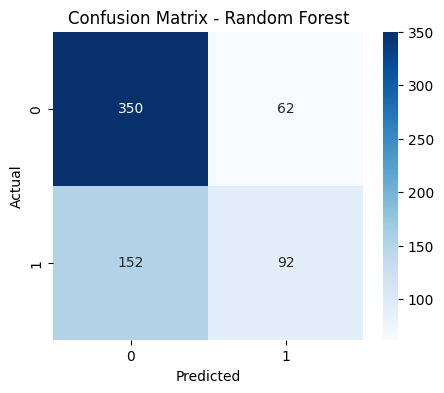

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

## Phân tích kết quả

Confusion matrix cho thấy mô hình có khả năng phân biệt tương đối tốt giữa hai lớp.

Tuy nhiên vẫn tồn tại một số trường hợp dự đoán sai khi các chỉ số chất lượng nước nằm gần ngưỡng an toàn.

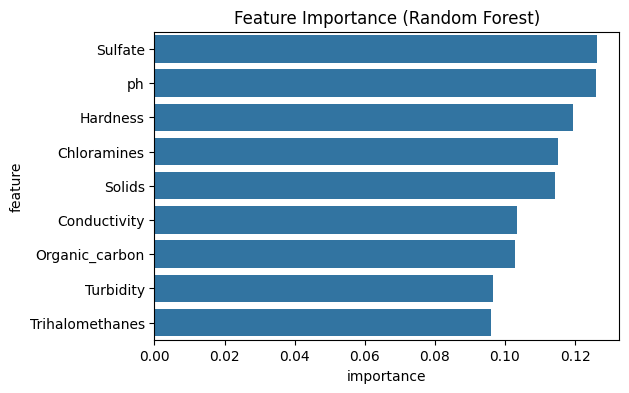

In [13]:
importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(data=feat_imp, x="importance", y="feature")

plt.title("Feature Importance (Random Forest)")
plt.show()

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [15]:
import joblib

joblib.dump(rf, "../outputs/random_forest_model.pkl")

['../outputs/random_forest_model.pkl']

In [16]:
results.to_csv("../outputs/classification_model_comparison.csv", index=False)